# Notebook Description

This time, we will use a collection of synthetically generated delivery driver IDs to create a forgery detection model pipeline. The IDs were designed manually using editing software filled with mocked field values for names, phone numbers, dates, and driver ID numbers.

Instead of building and training our own Convolutional Neural Network (CNN) model from scratch, we perform transfer learning by using a pretrained image classifier model (EfficientNet) by creating a custom classifier head. The CNN will then predict a probability of whether an ID image is genuine or forged as an output. Additionally, we also run add an OCR model to the pipeline to validate the fields on the IDs (formats, etc.). We will then combine these two scores as a weighted sum to make a definite verdict or prediction. 

## Import


### Modules

In [13]:
import torch
from torchvision import transforms, models
from torchvision.transforms import v2 
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
import cv2
import pytesseract

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import os
import re

pytesseract.pytesseract.tesseract_cmd = r'C:\\Program Files\\Tesseract-OCR\\tesseract.exe'

### Image Data

We have 30 total images and all of them are genuine. We will create forged versions of the images on the fly by using PyTorch transforms. 

In [14]:
genuine_dir = '../data/img/genuine'
forged_dir = '../data/img/forged'

In [15]:
genuine_imgs = os.listdir(genuine_dir)
print(f"Genuine images found: {len(genuine_imgs)}")
print(genuine_imgs[:5])  

Genuine images found: 30
['id_001.png', 'id_002.png', 'id_003.png', 'id_004.png', 'id_005.png']


## Defining Transforms

Below are the transforms we are to use in the pipeline. The mean and standard deviation to be used for normalization is kept exactly the same as the average color statistics of the ImageNet dataset. 

We define two transforms: a 'clean' transform and a 'forge' transform. Both do similar things such as converting the image into RGB mode and resizing to 224 x 224 pixels. A gray scale probability was added to allow the model to handle black and white/grayscaled images. As for the forge transform, we introduce transforms such as Gaussian blur and color jitter, as a means of simulating a poorly falsified ID. We also add random perspective and erasing to simulate tampering. 

In [16]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_stddev = [0.229, 0.224, 0.225]

clean_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.Resize((224, 224)), 
    transforms.RandomGrayscale(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_stddev)
])

forge_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.Resize((224, 224)), 
    transforms.RandomGrayscale(p=0.5),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1)),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_stddev),
])

## Transfer Learning Setup

The model we will use for the task is the EfficientNet model, which has already been pretrained on millions of images from the ImageNet database. Specifically, we choose the EfficientNet-B0 baseline model. Though it is currently not recommended anymore due to it being surpassed by newer architectures, we select it due to the small size of our synthetic dataset and the prototypical nature of this pipeline.

Since EfficientNet is already pretrained, we want to freeze its base layers. This is to ensure that its weights do not get updated during the training loop. With that, we perform transfer learning by creating our own classifier head. We set the following:
- Set dropout percentage to randomly turn off 20% of the neurons during training passes

- Define a linear transformation which sets how many predictors and output features we have. ImageNet's default input features are 224 x 224 = 50,176 pixels. And since the model is performing binary classification, we set output features to 1. 

- Finally, we use the Sigmoid function as our activation function (which is also a great fit for binary classification).

In [17]:
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(model.classifier[1].in_features, 1),
    nn.Sigmoid()
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=1, bias=True)
  (2): Sigmoid()
)


### Device Setup

The machine used for this task has a CUDA-enabled GPU. The training loop can be performed via CPU too but since we have capable hardware, we will set the device to the GPU to take advantage of the compute power it provides. 

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Loss Function and Optimizer

The loss function that the model will minimize will be Log loss or Binary Cross Entropy. It functions by significantly penalizing confident incorrect predictions by logarithmically increasing the penalty depending on whether the model makes a minor 'miscalculation' or a confident mistake. Say we have a true forged image (labeled 1), and model predicts it to be 82% (0.82) forged. Though the model is close to the true answer, it is still "unsure", hence it is hit with a relatively small penalty. In comparison, if that model predicted it to be 12% (0.12) forged, it means that the model is arrogantly answering, thus it is heavily penalized as it is incredibly far from the true label. 

We also use the Adaptive Movement Estimation (ADAM) optitmization algorithm as our optimizer. It works by automatically adjusting individual learning rates, rather than having a constant global learning rate nudge value. It also keeps track of the average direction of the model's weights to guide the model to the correct direction that would further minimize the loss function. 

In [19]:
model = model.to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

## Split

We load our image data and create separate paths for images to be used for training and validation. We set the test size to 20% resulting in an 80/20 split for training and testing. On top of that, each split gets a clean and a forged transformation, which creates an equal number of images per class for each split (24 (train) x 2 (clean and forged) = 48, 6 (val.) x 2 = 12. A total of 60 samples).

Due to the relatively small size of our dataset, a dedicated test set was not created in favor of maximizing our training data. The standard three-way train, validation, and test split would have provided a truly  unbiased estimate of our model's performance, but it would leave us with insufficient training samples for the model to learn patterns. 

In [20]:
img_paths = [os.path.join(genuine_dir, f) for f in os.listdir(genuine_dir)]

train_paths, val_paths = train_test_split(
    img_paths,
    test_size=0.2,
    random_state=42
)

print(f'Training image count: {len(train_paths)}')
print(f'Validation image count: {len(val_paths)}')

Training image count: 24
Validation image count: 6


### Dataloader

We then create a subclass implementation of PyTorch's abstract Dataset class for our dataloader. It requires us to implement the  *init*, *len*, and *getitem* methods. 

We simply pass the image paths and the transforms to the initializer of the class. The *len* method simply returns the number of samples in our dataset, which is just double the amount of our original images (2 classes each). Finally, *getitem* returns either a clean (genuine) or a forged image along with its label (0/1) as a tensor, depending on whether the index used to access the image paths is odd or even. The floor division by 2 ensures that the index lands on either of the consecutive versions of one image (again, one genuine and one forged). 

In [21]:
class ForgeryDataset(Dataset):
    def __init__(self, img_paths, clean_transform, forge_transform):
        self.img_paths = img_paths
        self.clean_transform = clean_transform
        self.forge_transform = forge_transform
    
    def __len__(self):
        return len(self.img_paths) * 2
    
    def __getitem__(self, idx):
        img_path = self.img_paths[idx // 2]
        img = Image.open(img_path)

        if idx % 2 == 0:
            return self.clean_transform(img), torch.tensor(0.0)
        else:
            return self.forge_transform(img), torch.tensor(1.0)

Then, we instantiate the dataset class for our training and validation data loaders. 

In [22]:
train_set = ForgeryDataset(train_paths, clean_transform, forge_transform)
val_set = ForgeryDataset(val_paths, clean_transform, forge_transform)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)

print(f"Training samples: {len(train_set)}")
print(f"Validation samples: {len(val_set)}")

Training samples: 48
Validation samples: 12


## Training Loop

The training loop for our transfer learning pipeline is as follows. For the forward pass, we set the model to *train* mode which enables neuron and allows weight updates; an important step for the train step. Then, each image-label pair in a batch is sent to the device (GPU) memory for computation. Gradients are then cleared at the start of each forward-backward pass to prevent gradient calculations from previous batches from accumulating. 

The model predictions are then compared with the image's true labels to update the training loss (BCE Loss). This loss is also used for backpropagation which determines neurons' individual contributions to the output, to which the optimizer (ADAM) then adjusts individual neuron connection weights. 

The validation step shares some of the processes done in the train step, except it is done with gradient tracking and calculation disabled (`no_grad`) for faster computation. The model is then set to *evaluation* mode which disables neuron dropout, ensuring that the model uses its full predictive capacity. Images and labels are then loaded onto the device as usual, after which a forward pass is performed. Note that there is no backward pass, as weight updates during the validation step will cause the model to memorize the data.

We then run the loop for a total of 15 epochs. Also, we want to save the model weights that resulted in the best validation loss. We do this by tracking the val. loss and saving the model state for each epoch. 

In [23]:
os.makedirs('../models',exist_ok=True)

In [24]:
n_epoch = 15

best_val_loss = float('inf')

for epoch in range(n_epoch):
    
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/forgery_detector.pth')

    print(f'Epoch {epoch+1}/{n_epoch} | Train Loss: {train_loss/len(train_loader):.4f} \
          | Val. Loss: {val_loss/len(val_loader):.4f}')

Epoch 1/15 | Train Loss: 0.6715           | Val. Loss: 0.6946
Epoch 2/15 | Train Loss: 0.5988           | Val. Loss: 0.6076
Epoch 3/15 | Train Loss: 0.4903           | Val. Loss: 0.5291
Epoch 4/15 | Train Loss: 0.4790           | Val. Loss: 0.4496
Epoch 5/15 | Train Loss: 0.4083           | Val. Loss: 0.3577
Epoch 6/15 | Train Loss: 0.4116           | Val. Loss: 0.3175
Epoch 7/15 | Train Loss: 0.3646           | Val. Loss: 0.3187
Epoch 8/15 | Train Loss: 0.3394           | Val. Loss: 0.2762
Epoch 9/15 | Train Loss: 0.3356           | Val. Loss: 0.2088
Epoch 10/15 | Train Loss: 0.3319           | Val. Loss: 0.1807
Epoch 11/15 | Train Loss: 0.3566           | Val. Loss: 0.2790
Epoch 12/15 | Train Loss: 0.2655           | Val. Loss: 0.1561
Epoch 13/15 | Train Loss: 0.2863           | Val. Loss: 0.1997
Epoch 14/15 | Train Loss: 0.2295           | Val. Loss: 0.1357
Epoch 15/15 | Train Loss: 0.2452           | Val. Loss: 0.2357


With 15 epochs, train and validation loss values generally follow a decreasing trend, indicating that the model was learning decently well. Notice slight fluctuations in validation loss from epochs 10 onwards. Epoch 14 has the lowest validation loss of 0.1357 (the lowest out of all), whereas epoch 15 spikes the loss by 0.10 (0.2357). Such fluctuations may be due to the small size of the validation set. Since we have only 12 images as validation samples, one misclassification significantly impacts the loss. This is a limitation of using small datasets for evaluation, hence using a larger dataset which provides more validation samples, would help stabilize the loss. 

### Metrics

The classification report and confusion matrix is shown below. Immediately, we notice perfect true positives and true negatives, resulting in a perfect score for precision, recall, and F1 score. Aside from the small validation set size, factors such as the synthetic nature of the dataset and EfficientNet's capabilities can be attributed to such scores. 

The dataset was created in a way that the visual gap between genuine and forged images were artificially consistent compared to real-world forgeries. The forged versions were simply corruptions of genuine images using blur, noise and, random erasures which is distinctly learnable. Moreover, EfficientNet-B0, which is a pretrained model, already recognizes such visual inconsistencies which makes genuine and forged comparisons somewhat 'trivial' to it. 

The scores do not necessarily mean that the model is overfitting, since the random transforms that are freshly applied at each epoch ensures that the model does not see the exact same forged version twice. Hence, the perfect scores more likely reflects the artificial simplicity of the synthetic data rather than the model memorizing the training set.  

Knowing this, forgery detection cannot rely on this CNN model alone, since ID legitimacy cannot be determined solely from image quality. Thus, we pair it with an OCR model to check for field inconsistencies (dates, ID numbers, etc.) in order to create a weighted score for more robust detection. 

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00         6
      Forged       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



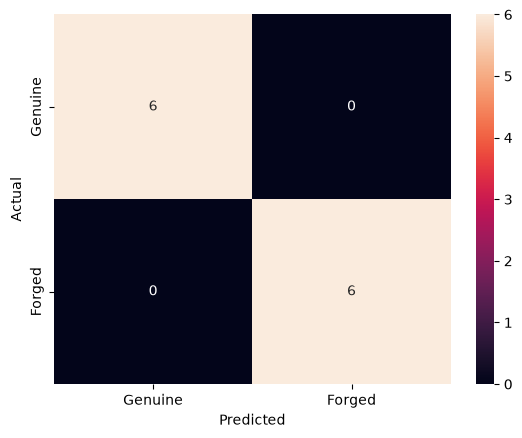

In [25]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze(1)
        preds = (outputs >= 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Genuine','Forged']))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(
    cm, annot=True, fmt='d', xticklabels=['Genuine','Forged'], yticklabels=['Genuine','Forged']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## The OCR Model

Optical Character Recognition (OCR) models allow us to extract text data from images. Here, we will use it to extract values from the ID fields to detect text inconsistencies indicative of forgery. Since we do not have a fully functional database of delivery drivers to cross-check ID data, we will simply apply RegEx rules to check whether an ID field follows a known format. 


We create a helper method to extract image text data from a known image path. We use PyTesseract as the OCR engine used to extract the text fields from the image. 

In [ ]:
def extract_fields(img_path):
    img = cv2.imread(img_path)
    text = pytesseract.image_to_string(img)

    return text

In [27]:
sample = train_paths[0]
extract_fields(sample)

'=a N\n\nXYZ LOGISTICS\n\nKENNETH DOMINGO\n\nDriver\n\nPhone : +63 937 251 9533\nExpiry : 08/20/2031\n\n‘0RV300723\n'

Notice a small inconsistency for the driver ID number. The OCR engine reads it as '0RV', when in the true format is 'DRV'. 

### RegEx Rules

As stated earlier, the field validation step only works by checking if a field follows a specified format, rather than querying a database to check if such a value exists. Thus, our model would only reliably capture altered IDs with tampered template formats, or low-effort counterfeits. An ID with proper formatting would definitely bypass this detection, since no database cross-checking is done. For the purpose of project demonstration, we limit our scope to the former case of IDs. 

The `validate_fields` method performs four simple formatting checks:
1. Presence of a driver name
2. A properly formatted driver ID number, following DRVXXXXXX (X is a number)
3. A phone number with the PH country code and is 11 digits long (+63 XXX XXX XXXX); and
4. A valid expiration date with format MM-DD-YYYY

The method then returns an anomaly score, which is the number of anomalies detected for all fields checked. 

In [35]:
from datetime import datetime

In [36]:
def validate_fields(text, verbose=False):
    anomalies = 0 
    total_checks = 4

    name_matches = re.findall(r'[A-Z]{2,}(?:\s[A-Z]{2,})+', text)
    exclude = ['XYZ', 'LOGISTICS', 'Driver']
    valid_names = [m for m in name_matches if not any(word in m for word in exclude)]

    if not valid_names:
        if verbose: print("Anomaly detected: Name")
        anomalies += 1
    else:
        if verbose: print(f"Name OK: {valid_names[0]}")
    
    
    driver_match = re.search(r'DRV\d{6}', text)
    if not driver_match:
        if verbose: print("Anomaly detected: Driver ID")
        anomalies += 1
    else:
        if verbose: print(f"Driver number OK: {driver_match.group()}")
    
    
    phone_match = re.search(r'\+63\s?\d{3}\s?\d{3}\s?\d{4}', text)
    if not phone_match:
        if verbose: print("Anomaly detected: Phone number")
        anomalies += 1
    else:
        if verbose: print(f"Phone number OK: {phone_match.group()}")
    
    
    expiry_match = re.search(r'\d{2}/\d{2}/\d{4}', text)
    if not expiry_match:
        if verbose: print("Anomaly detected: Expiry date")
        anomalies += 1
    else:
        try:
            expiry_date = datetime.strptime(expiry_match.group(), '%m/%d/%Y')
            if expiry_date < datetime.now():
                if verbose: print(f"Anomaly detected: Expiry date is in the past ({expiry_match.group()})")
                anomalies += 1
            else:
                if verbose: print(f"Expiry date OK: {expiry_match.group()}")
        except ValueError:
            if verbose: print(f"Anomaly detected: Invalid expiry date ({expiry_match.group()})")
            anomalies += 1
    
    anomaly_score = anomalies / total_checks
    if verbose: print(f"\nAnomaly Score: {anomaly_score:.2f} ({anomalies}/{total_checks} fields flagged)")

    return anomaly_score

## Ensemble Score

The ensemble score is a weighted score combining the CNN model's prediction probability and the OCR model's anomaly score. This was created to prevent forgery classifications from depending only on image quality. 

A 70% weight was given to the CNN model's score since it performed well on the validation set and is also the primary detection mechanism. The OCR model gets a complementary 30% weight since it has slight reliability limitations (such as the '0RV', 'DRV' instance earlier) which makes it a supporting signal instead. 

Thus, images with an ensemble score of 0.5 or greater are considered *LIKELY FORGED*, whereas those with scores less than 0.5 are *LIKELY GENUINE*.

In [29]:
def get_cnn_score(img_path):
    img = Image.open(img_path).convert('RGB')
    tensor = clean_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        score = model(tensor).item()
    return score

def ensemble_score(img_path, cnn_weight=0.7, ocr_weight=0.3):
    cnn_score = get_cnn_score(img_path)

    text = extract_fields(img_path)
    ocr_score = validate_fields(text)

    combined_score = (cnn_weight * cnn_score) + (ocr_weight * ocr_score)

    print(f"\nCNN Score: {cnn_score:.4f}")
    print(f"OCR Anomaly Score: {ocr_score:.4f}")
    print(f"Ensemble Score: {combined_score:.4f}")
    print(f"Verdict: LIKELY {'FORGED' if combined_score >= 0.5 else 'GENUINE'}")
    
    return combined_score

### Ensemble Scoring Test

We then grab a forged image example to test the ensemble. The image here has a slight shift in perspective, the barcode slightly tilted, and the logo out of place. Also, the phone number is not in the correct expected format. Getting the ensemble score for this image returns high values for both the CNN and OCR anomaly scores, confirming the image and field inconsistencies. 

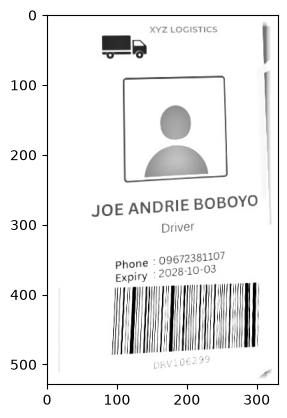

In [38]:
test_path = '../data/img_test/forged/forged_002.jpg'

img = Image.open(test_path)
plt.imshow(img)
plt.show()

In [39]:
ensemble_score(test_path)


CNN Score: 0.7254
OCR Anomaly Score: 0.7500
Ensemble Score: 0.7328
Verdict: LIKELY FORGED


0.73277468085289

We also get the ensemble score for a genuine example. Fields appear to be correctly formatted and thte image appears mostly fine, apart from the whited out border. The CNN model thinks that this image is likely forged with a score of ~0.57, which may be due to the grayscaled nature of the photo and inconsistencies near the borders. The OCR model, however, balances out the ensemble score with it returning 0.25. This is likely due to it misinterpreting the 'DRV' ID number sequence as described earlier. Overall, the ensemble score for this image is 0.48, which means that the image is likely genuine.

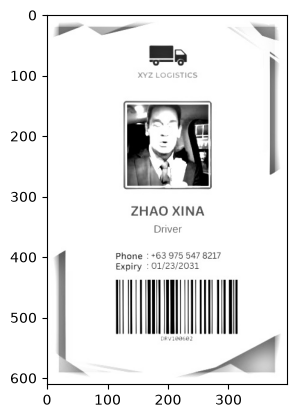

In [40]:
test_path = '../data/img_test/genuine/id_003.jpg'

img = Image.open(test_path)
plt.imshow(img)
plt.show()

In [41]:
ensemble_score(test_path)


CNN Score: 0.5789
OCR Anomaly Score: 0.2500
Ensemble Score: 0.4803
Verdict: LIKELY GENUINE


0.48025723099708556